In [ ]:
%load_ext autoreload
%autoreload 2

from spatial_tcr.utils import switch_cwd_to_root

switch_cwd_to_root()

import spatialtools as st

figure_dir = "figures/revision/supplement-extra"
st.utils.setup_plotting(figure_dir)

import os

import scanpy as sc

from spatial_tcr.clonal_expansion import (
    get_avbv_assignment_counts,
    plot_avbv_assignment_counts,
)
from spatial_tcr.tcr import get_tcr_genes

## Load data

In [2]:
data_dir = "data/xenium/processed"
path = f"{data_dir}/08.1-kidney_tcr_clonal_clusters.h5ad"
adata = sc.read_h5ad(path)

# remove control samples
adata = adata[adata.obs["condition"] == "ANCA"].copy()
adata

AnnData object with n_obs × n_vars = 389390 × 431
    obs: 'sample', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'condition', 'cc', 'cell_type_no_tcr', 'cell_type_no_tcr_prob', 'tcell_subtype', 'cell_type_l1', 'cell_type_l2', 'is_ATL', 'is_B', 'is_CNT', 'is_DCT', 'is_DTL', 'is_EC', 'is_FIB', 'is_IC', 'is_MAST', 'is_MC', 'is_MDC', 'is_Mac', 'is_N', 'is_NEU', 'is_PC', 'is_PEC', 'is_PL', 'is_POD', 'is_PT', 'is_PapE', 'is_T', 'is_TAL', 'is_VSM/P', 'is_cDC', 'is_cycMNP', 'is_glom. EC', 'is_pDC', 'is_unknown', 'leiden', 'glom_annot', 'in_glom', 'tcell_density_group', 'tcell_density', 'tcell_infiltrate', 'cell_type_l1.1', 'av_

## Per sample probe proportion comparison

In [3]:
av_genes, bv_genes, dv_genes, gv_genes, tv_genes = get_tcr_genes(adata)

Found 35 TRAV genes, 31 TRBV genes, 3 TRDV genes, 14 TRGV genes


In [4]:
adata.obs.columns

Index(['sample', 'x_centroid', 'y_centroid', 'transcript_counts',
       'control_probe_counts', 'control_codeword_counts',
       'unassigned_codeword_counts', 'deprecated_codeword_counts',
       'total_counts', 'cell_area', 'nucleus_area', 'slide',
       'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts',
       'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes',
       'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts',
       'condition', 'cc', 'cell_type_no_tcr', 'cell_type_no_tcr_prob',
       'tcell_subtype', 'cell_type_l1', 'cell_type_l2', 'is_ATL', 'is_B',
       'is_CNT', 'is_DCT', 'is_DTL', 'is_EC', 'is_FIB', 'is_IC', 'is_MAST',
       'is_MC', 'is_MDC', 'is_Mac', 'is_N', 'is_NEU', 'is_PC', 'is_PEC',
       'is_PL', 'is_POD', 'is_PT', 'is_PapE', 'is_T', 'is_TAL', 'is_VSM/P',
       'is_cDC', 'is_cycMNP', 'is_glom. EC', 'is_pDC', 'is_unknown', 'leiden',
       'glom_annot', 'in_glom', 'tcell_density_group', 'tcell_density',
   

In [5]:
sample_mapping = {k: f"S{i}" for i, k in enumerate(adata.obs["sample"].unique())}
adata.obs["sample_short"] = adata.obs["sample"].map(sample_mapping)

In [6]:
ad_t = adata[adata.obs["cell_type_l1"] == "T"].copy()

In [7]:
result = get_avbv_assignment_counts(
    ad_t, av_genes, bv_genes, layer="counts", sample_key="sample_short"
)

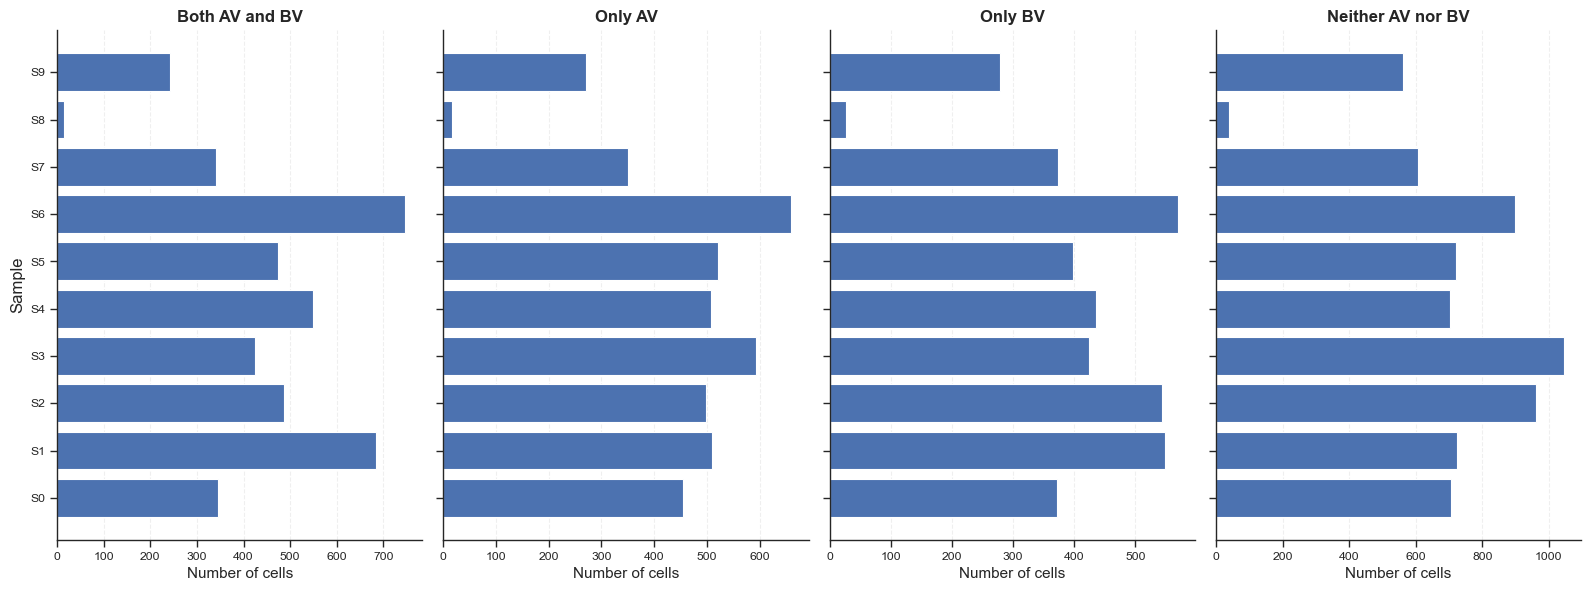

In [8]:
_fig, _axes = plot_avbv_assignment_counts(result)

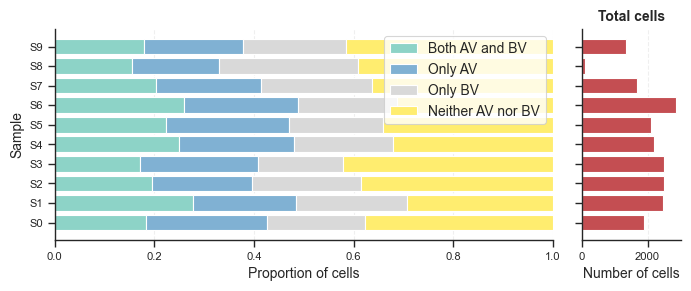

In [11]:
_fig, _axes = plot_avbv_assignment_counts(
    result,
    figsize=(7, 3),
    save_path=os.path.join(figure_dir, "avbv_assignment_counts.pdf"),
    title=None,
    normalize=True,
)